In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import time
from tqdm import tqdm

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler


total_start = time.time()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

WORKDIR = Path().resolve()                  # auto: wherever the notebook lives
REPO_ROOT = WORKDIR.parents[1]             # still assumes scripts/MODE_bend_wg/ structure
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_MODE_bend_wg"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ligentic_NU_1_TapeOut_April2026\scripts\MODE_bend_wg
Data will be saved to: D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_MODE_bend_wg


In [2]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'MODE_Calculation.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
results = []

LambdaStart    = 1525E-9
LambdaStop     = 1575E-9

Width          = 1600E-9
Height         = 800E-9
Radius         = 20E-6
Gap            = 600E-9
Length         = 4 * Radius
YLength        = Radius

use_index      = True
Index          = 1.97
Material       = "Si3N4 (Silicon Nitride) - Luke"

BackgroundMaterial = "SiO2 (Glass) - Palik"
FrequencyPoints    = round(2000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 100000


In [4]:
#---------------------------------------------------------------
# Bend WG setup
#---------------------------------------------------------------

f.addrect()
f.set('x', 0)
f.set('y', 0)
f.set('x span', 0.25 * Radius)
f.set('y span', Width)
f.set('z', 0)
f.set('z span', Height)

if use_index:
    f.set('material', '<Object defined dielectric>')
    f.set('index', Index)
    n_mat = Index
else:
    f.set('material', Material)
    n_mat = np.real(f.getindex(Material, 1550e-9))
#---------------------------------------------------------------
# Mode solver 
#---------------------------------------------------------------

f.addfde()
f.set("solver type", "2D X Normal")
f.set("x",0)  # Aligned with the right ring
f.set("y", 0)  # Centered in Y
f.set("y span", 2 * Width)
f.set("z", 0)  # Centered in Z
f.set("z span", 2 * Width)
f.set("wavelength", (LambdaStart + LambdaStop) / 2)
f.set("background material", BackgroundMaterial)
f.set("bent waveguide", 1)
f.set("bend radius", Radius)
f.set("bend orientation", 0)

#---------------------------------------------------------------
# Run
#---------------------------------------------------------------
f.findmodes()


20.0

In [5]:

#---------------------------------------------------------------
# Results and plots
#---------------------------------------------------------------

# Extract scalars
neff = f.getdata("FDE::data::mode1", "neff").flat[0]
ng = f.getdata("FDE::data::mode1", "ng").flat[0]
loss = f.getdata("FDE::data::mode1", "loss")
te_frac = f.getdata("FDE::data::mode1", "TE polarization fraction")
aeff = f.getdata("FDE::data::mode1", "mode effective area")

# Extract fields
Ex = np.squeeze(f.getdata("FDE::data::mode1", "Ex"))
Ey = np.squeeze(f.getdata("FDE::data::mode1", "Ey"))
Ez = np.squeeze(f.getdata("FDE::data::mode1", "Ez"))

results.append({
    'width_nm': Width * 1e9,
    'radius_um': Radius * 1e6,
    'neff': np.real(neff),
    'ng': np.real(ng),
    'loss_dB_cm': np.real(loss) / 100,
    'te_frac': np.real(te_frac),
    'aeff_um2': np.real(aeff) * 1e12,
    'Ex': Ex,
    'Ey': Ey,
    'Ez': Ez
})

print(f"  neff={np.real(neff):.4f}, ng={np.real(ng):.3f}, loss={np.real(loss)/100:.3f} dB/cm")

  neff=1.8144, ng=2.063, loss=0.000 dB/cm


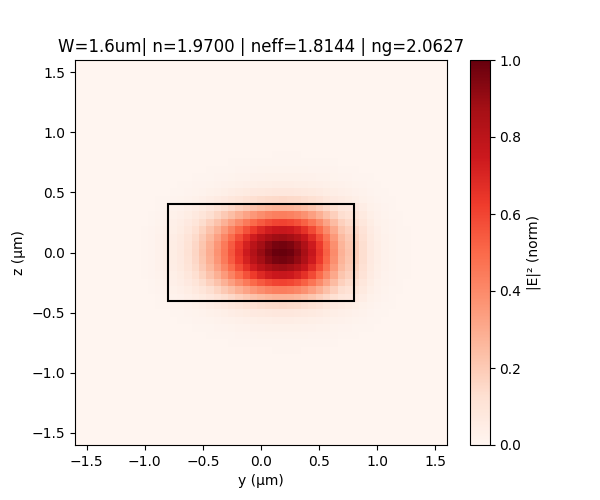

In [6]:
from matplotlib.patches import Rectangle   # NEW

E_total = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
E_norm  = E_total / E_total.max()

y_span = 2*Width*1E6
z_span = y_span

plt.figure(figsize=(6,5))
extent = [-y_span/2, y_span/2, -z_span/2, z_span/2]

plt.imshow(
    E_norm.T,
    origin='lower',
    cmap='Reds',
    aspect='auto',
    extent=extent
)

# ---- STRUCTURE OUTLINE (NEW) ----
rect = Rectangle(
    (-Width*1e6/2, -Height*1e6/2),   # lower-left corner
    Width*1e6,                       # width along y
    Height*1e6,                      # height along z
    linewidth=1.5,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(rect)
# --------------------------------

plt.colorbar(label='|E|² (norm)')
plt.xlabel('y (µm)')
plt.ylabel('z (µm)')
plt.title(f'W={Width*1E6:.1f}um| n={np.real(n_mat):.4f} | neff={np.real(neff):.4f} | ng={np.real(ng):.4f}')
plt.gcf().set_dpi(200)
zoom_factory(plt.gca())
# mplcursors.cursor(hover=True) 
plt.show()
